# 02. MetroPT-3 domain features & operating shifts

Notebook 01 established the ground rules:
- the compressor is **loaded when `COMP == 0`**
- ~7 days of **frozen-logger** minutes must be masked
- the four air leaks show up as long, continuous loading and hot oil

This notebook turns 10 s telemetry into 1-minute features that describe the compressor's *dynamic equilibrium*. An air leak upsets that equilibrium in recognisable ways:

| Leak effect | Feature(s) |
|---|---|
| Pressure bleeds away while idle | `idle_decay_rate_60m`: reservoir pressure lost per minute while unloaded |
| Compressor must restart more often | `load_starts_per_hour` |
| ...and run longer to restore pressure, or never unload | `duty_cycle_{15m,60m,6h}`, `max_load_run_min_60m` |
| Sustained load heats the oil | `oil_temp_excess_24h`: 60 min oil temperature minus its own trailing 24 h level (removes the Feb→Jul seasonal drift) |
| Electrical and pneumatic stress | `motor_current_loaded_60m`, `motor_current_std_15m`, `delta_p_loaded_60m` (TP2−TP3 while loaded), `reservoir_min_60m`, `lps_frac_60m` |

**Engineering rules**, all implemented in `src/compressor_guard/features.py`:
1. **Causal only.** Every window is trailing `(t − W, t]`. No centred windows, no back-fill (the earlier draft used `.bfill()`, which leaks future values into the past).
2. **Frozen minutes are dropped**, and empty minutes are never invented.
3. **Everything is built from per-minute sums/extremes.** So `stream/state.py` can reproduce the features incrementally, and `tests/test_stream_parity.py` proves the two agree.
4. **Drift z-scores** use statistics from the healthy training window only (1 Feb – 10 Apr, which ends 8 days before F1).

In [1]:
import sys
import warnings
from pathlib import Path

# Make `src/` importable whether the notebook runs from notebooks/ or the repo root
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from compressor_guard.config import FIGURES_DIR, load_params

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
params = load_params()

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
                     "axes.titleweight": "bold", "axes.titlesize": 11})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
FAIL_COLOR, ALERT_COLOR, FROZEN_COLOR = "#d62728", "#ff7f0e", "#7f7f7f"

from compressor_guard.data import load_failures, load_labelled_metropt
from compressor_guard.features import (DRIFT_COLUMNS, FEATURE_COLUMNS, build_feature_table,
                                       save_baseline, save_features_parquet)
from compressor_guard.models import training_mask

df_clean = load_labelled_metropt(params)          # builds the cache from the CSV if notebook 01 was skipped
failures = load_failures(ROOT / "config/failures.yaml")
print(f"{len(df_clean):,} raw rows loaded")

1,516,948 raw rows loaded


## 1. Build the feature table

In [2]:
feats, baseline = build_feature_table(df_clean, params, failures=failures)
print(f"{len(feats):,} scored minutes | {feats.attrs['frozen_minutes']:,} frozen minutes dropped | "
      f"{len(FEATURE_COLUMNS)} features + {len(DRIFT_COLUMNS)} drift z-scores")
print("\nHealthy-baseline statistics used for drift z-scores (mean, std):")
display(pd.DataFrame(baseline, index=["mean", "std"]).T.round(4))
feats[["timestamp", "shift", "duty_cycle_60m", "load_starts_per_hour", "max_load_run_min_60m",
       "idle_decay_rate_60m", "oil_temp_excess_24h", "motor_current_loaded_60m"]].iloc[1000:1005]

242,498 scored minutes | 10,222 frozen minutes dropped | 26 features + 4 drift z-scores

Healthy-baseline statistics used for drift z-scores (mean, std):


,mean,std
duty_cycle_60m,0.1180,0.1629
motor_current_mean_60m,1.6892,0.9122
oil_temp_mean_60m,59.3317,5.3188
idle_decay_rate_60m,0.0869,0.0340


,timestamp,shift,duty_cycle_60m,load_starts_per_hour,max_load_run_min_60m,idle_decay_rate_60m,oil_temp_excess_24h,motor_current_loaded_60m
1000,2020-02-01 16:44:00,Shift 2 (14-22),0.066116,2.0,1.983333,0.086956,3.767578,5.836771
1001,2020-02-01 16:45:00,Shift 2 (14-22),0.077135,3.0,1.983333,0.087474,3.705818,5.800000
1002,2020-02-01 16:46:00,Shift 2 (14-22),0.093664,3.0,1.983333,0.087502,3.647533,5.840074
1003,2020-02-01 16:47:00,Shift 2 (14-22),0.096419,3.0,1.983333,0.090540,3.620465,5.849714
1004,2020-02-01 16:48:00,Shift 2 (14-22),0.096419,3.0,1.983333,0.091993,3.622037,5.849714


## 2. The "healthy" window is not all healthy

Before training on Feb 1 – Apr 10 as "normal", we check it for leak-like behaviour: periods where the compressor ran continuously for over an hour. No failure labels are involved.

In [3]:
x = feats.set_index("timestamp")
hot = x["max_load_run_min_60m"] > 60
run_id = (hot != hot.shift()).cumsum()
episodes = (x[hot].groupby(run_id[hot])
            .apply(lambda g: pd.Series({
                "start": g.index[0], "end": g.index[-1],
                "hours": (g.index[-1] - g.index[0]).total_seconds() / 3600,
                "max_oil_C": g["oil_temp_mean_60m"].max(),
                "min_reservoir_bar": g["reservoir_min_60m"].min(),
                "reported_failure": ",".join(sorted(set(g.loc[g["is_failure"], "failure_id"]))) or "-"}))
            .query("hours >= 1").reset_index(drop=True))
tr_end = pd.Timestamp(params["metropt"]["train_split"]["end"])
episodes["in_training_window"] = episodes["start"] <= tr_end
display(episodes.round(2))

,start,end,hours,max_oil_C,min_reservoir_bar,reported_failure,in_training_window
0,2020-03-06 22:42:00,2020-03-06 23:58:00,1.27,75.60,8.04,-,True
1,2020-03-12 01:16:00,2020-03-12 12:48:00,11.53,77.31,0.88,-,True
2,2020-03-27 08:12:00,2020-03-27 12:37:00,4.42,76.88,8.03,-,True
3,2020-03-29 00:05:00,2020-03-29 19:49:00,19.73,82.44,0.95,-,True
4,2020-04-12 12:50:00,2020-04-13 00:35:00,11.75,75.22,7.90,-,False
5,2020-04-18 01:24:00,2020-04-19 02:54:00,25.50,76.81,0.95,F1,False
6,2020-05-13 14:44:00,2020-05-14 01:18:00,10.57,70.01,7.08,-,False
7,2020-05-19 23:22:00,2020-05-20 19:48:00,20.43,75.18,7.46,-,False
8,2020-05-30 00:15:00,2020-05-30 06:55:00,6.67,76.32,8.06,F2,False
9,2020-06-03 11:06:00,2020-06-03 12:07:00,1.02,76.46,7.98,-,False


Several multi-hour full-load episodes with collapsing reservoir pressure and hot oil **do not appear in the failure report**. That includes 12 Mar (11.5 h, reservoir < 1 bar) and 28–29 Mar (19.7 h, oil 82 °C), both inside the training window, plus 12 Apr, 13 May and 19–20 May in the test period.

Decisions:
- The two in-window episodes are **excluded from model fitting** (`metropt.train_exclude` in `params.yaml`). Letting a detector learn "an hours-long leak signature is normal" would blunt it. This uses only the signal, not failure labels.
- They stay in the data, and every later episode is scored normally. In the back-test, alerts on the May episodes count as **false alarms**, even though they may well be unreported leaks. The false-alarm rates are therefore conservative (upper bounds).

Training minutes: 83,158 (of 85,244 in the window; 2,086 excluded)


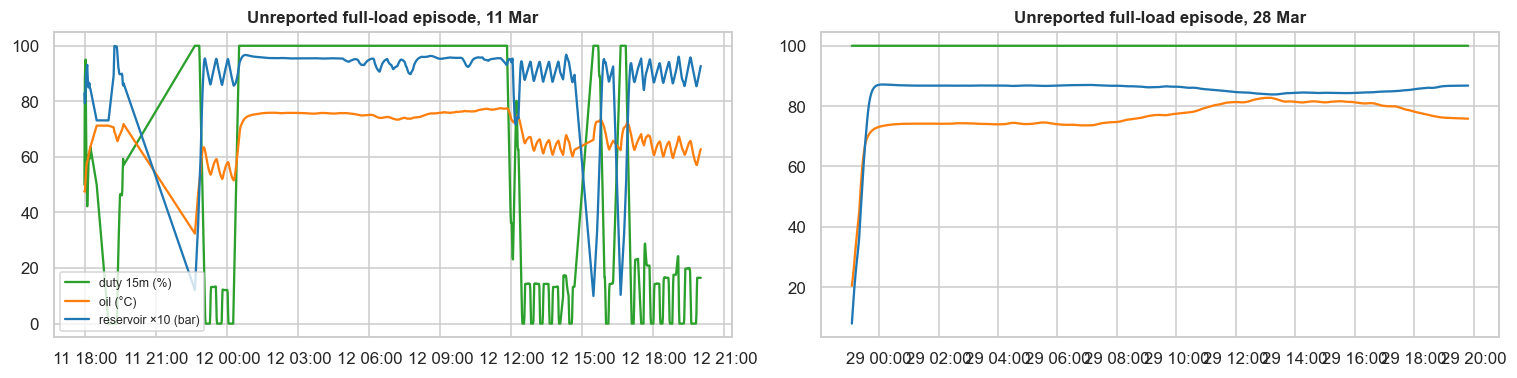

In [4]:
mask = training_mask(feats, params)
print(f"Training minutes: {mask.sum():,} (of {(feats['timestamp'] <= tr_end).sum():,} in the window; "
      f"{(feats['timestamp'] <= tr_end).sum() - mask.sum():,} excluded)")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for ax, (a, b) in zip(axes, [("2020-03-11 12:00", "2020-03-12 20:00"), ("2020-03-28 12:00", "2020-03-30 00:00")]):
    w = x.loc[a:b]
    ax.plot(w.index, w["duty_cycle_15m"] * 100, color="#2ca02c", label="duty 15m (%)")
    ax.plot(w.index, w["oil_temp_mean_15m"], color="#ff7f0e", label="oil (°C)")
    ax.plot(w.index, w["reservoir_mean_15m"] * 10, color="#1f77b4", label="reservoir ×10 (bar)")
    ax.set_title(f"Unreported full-load episode, {pd.Timestamp(a):%d %b}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %H:%M"))
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

## 3. Operating shifts (healthy period)

,minutes,duty_cycle_60m,load_starts_per_hour,idle_decay_bar_min,motor_current_loaded_A,oil_temp_C
shift,,,,,,
Shift 1 (06-14),"29,786",10.3%,2.35,0.086,5.91,58.8
Shift 2 (14-22),"29,557",9.4%,2.55,0.090,5.88,60.3
Shift 3 (22-06),"23,815",9.5%,2.21,0.083,5.93,57.4


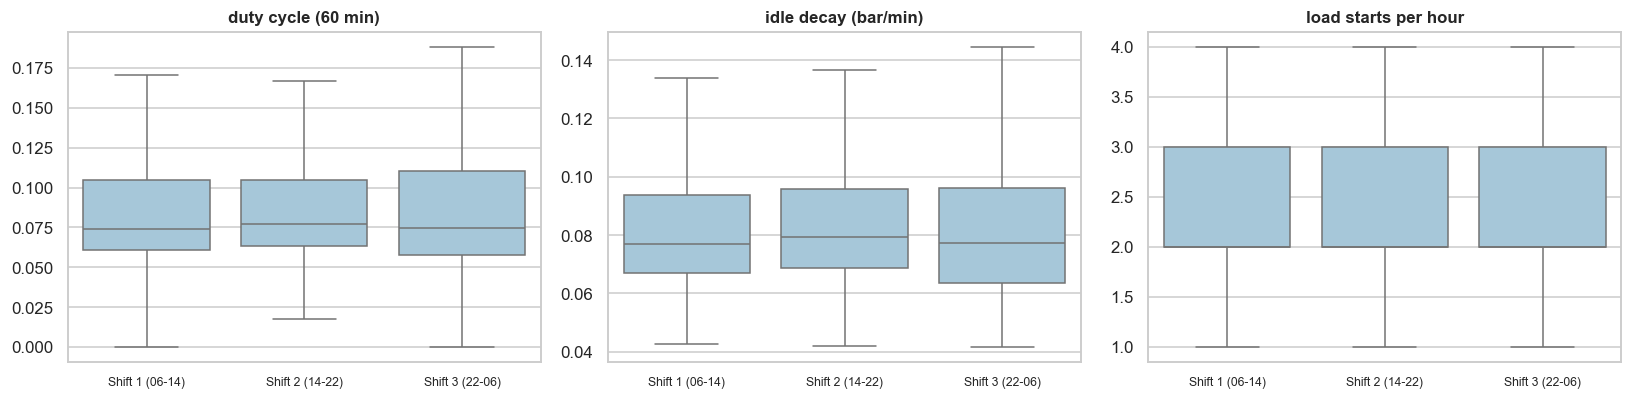

In [5]:
healthy = feats[mask]
shift_eval = healthy.groupby("shift", observed=True).agg(
    minutes=("duty_cycle_60m", "size"), duty_cycle_60m=("duty_cycle_60m", "mean"),
    load_starts_per_hour=("load_starts_per_hour", "mean"), idle_decay_bar_min=("idle_decay_rate_60m", "mean"),
    motor_current_loaded_A=("motor_current_loaded_60m", "mean"), oil_temp_C=("oil_temp_mean_60m", "mean"))
display(shift_eval.style.format({"minutes": "{:,}", "duty_cycle_60m": "{:.1%}", "load_starts_per_hour": "{:.2f}",
                                 "idle_decay_bar_min": "{:.3f}", "motor_current_loaded_A": "{:.2f}",
                                 "oil_temp_C": "{:.1f}"}))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, col, lab in zip(axes, ["duty_cycle_60m", "idle_decay_rate_60m", "load_starts_per_hour"],
                        ["duty cycle (60 min)", "idle decay (bar/min)", "load starts per hour"]):
    sns.boxplot(data=healthy, x="shift", y=col, ax=ax, showfliers=False, color="#9ecae1")
    ax.set(title=lab, xlabel="", ylabel="")
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

Shift 3 (night, parked train) has lower duty and fewer starts, but the *leak-sensitive* quantities (idle decay rate, loaded current) are similar across shifts. A single global threshold is reasonable, and notebook 03 checks whether false alarms cluster by shift.

## 4. Precursors in the 72 h before each failure

Curves are scaled by their healthy 99th percentile (dashed line = 1). Breaks in the lines are gaps or frozen-logger minutes.

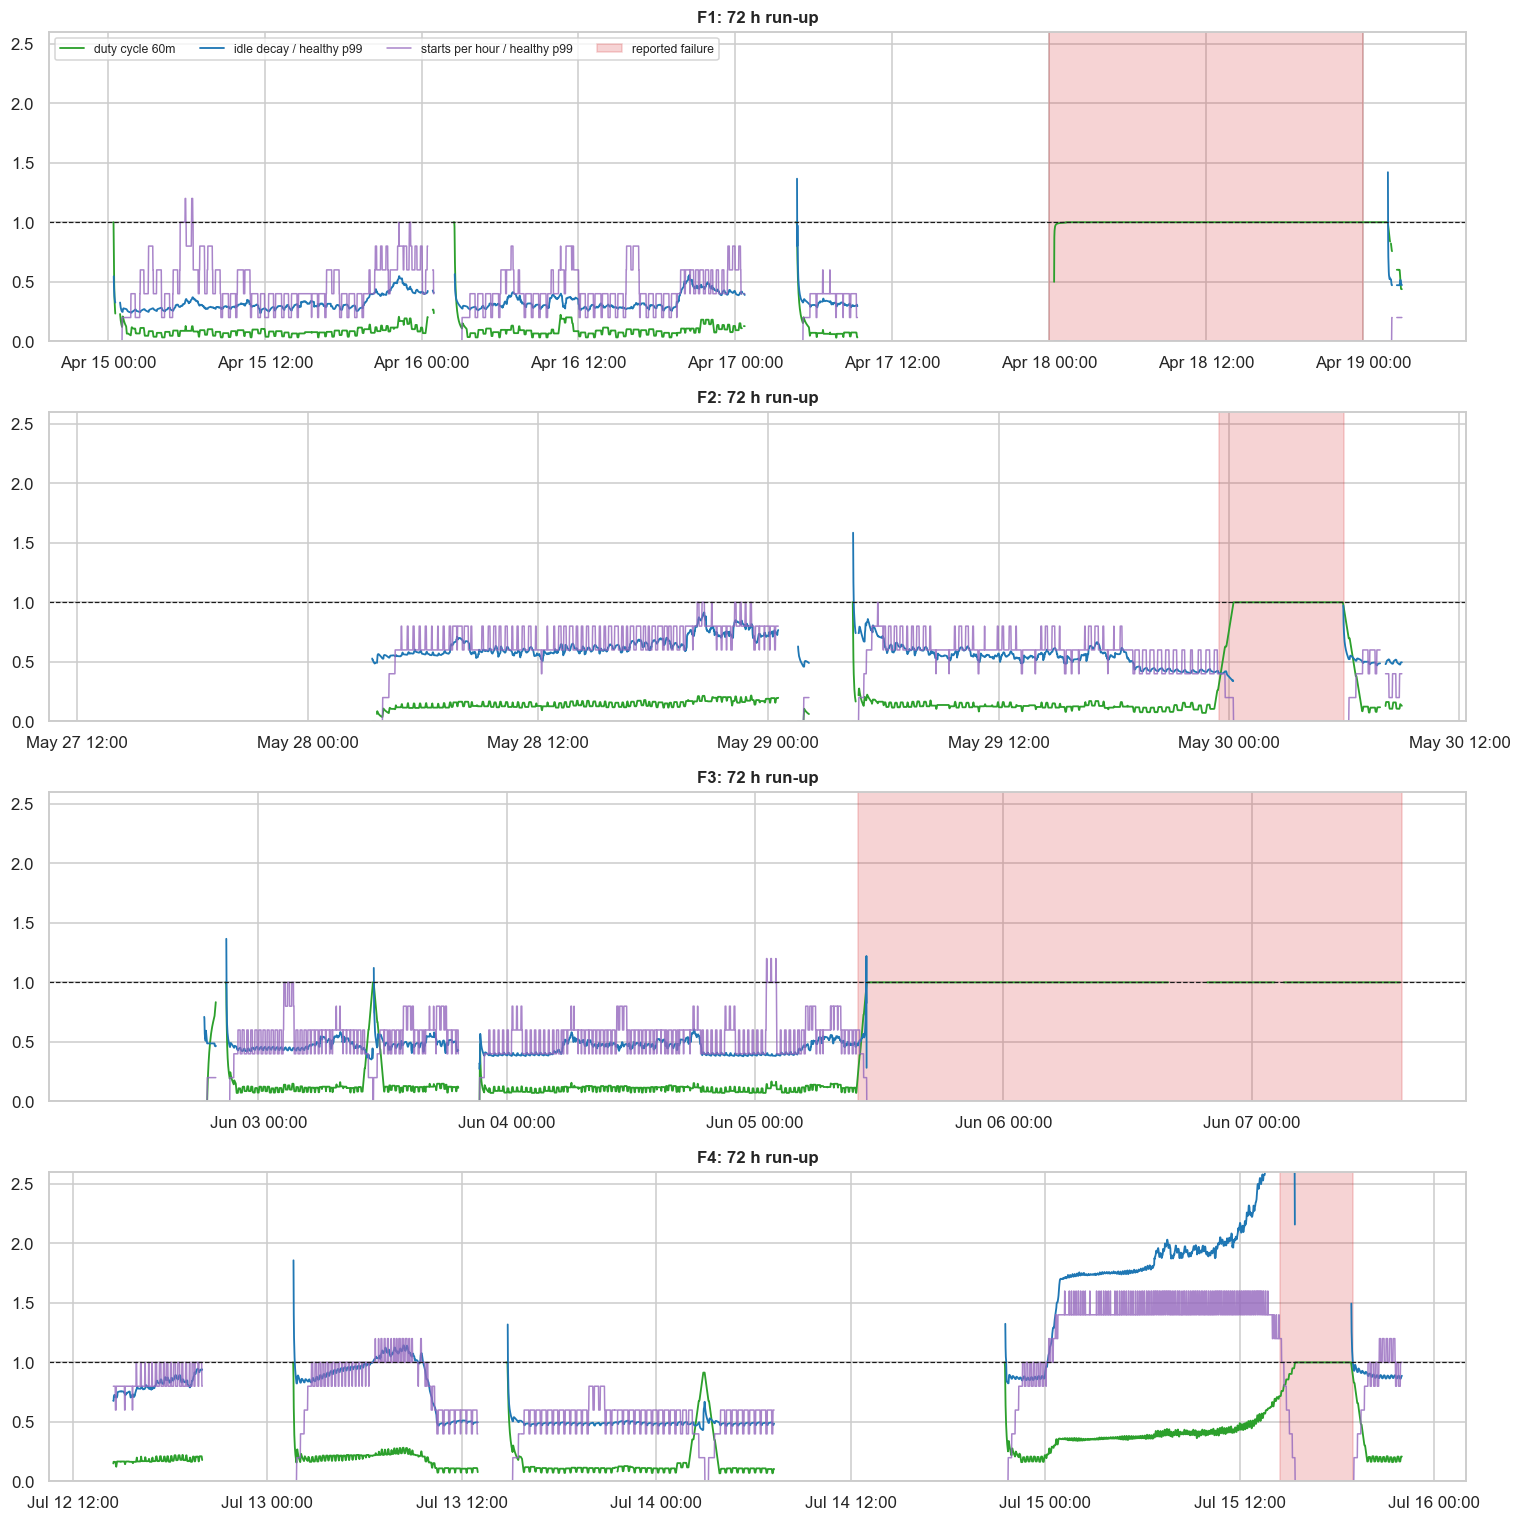

In [6]:
p99 = healthy[["duty_cycle_60m", "idle_decay_rate_60m", "load_starts_per_hour"]].quantile(0.99)
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, f in zip(axes, failures):
    # asfreq -> gaps and frozen minutes become NaN, so lines break instead of bridging them
    w = x.loc[f["start"] - pd.Timedelta(hours=72): f["end"] + pd.Timedelta(hours=3)].asfreq("1min")
    ax.plot(w.index, w["duty_cycle_60m"], color="#2ca02c", lw=1.2, label="duty cycle 60m")
    ax.plot(w.index, w["idle_decay_rate_60m"] / p99["idle_decay_rate_60m"], color="#1f77b4", lw=1.2,
            label="idle decay / healthy p99")
    ax.plot(w.index, w["load_starts_per_hour"] / p99["load_starts_per_hour"], color="#9467bd", lw=1,
            alpha=0.8, label="starts per hour / healthy p99")
    ax.axhline(1.0, color="k", ls="--", lw=0.8)
    ax.axvspan(f["start"], f["end"], color=FAIL_COLOR, alpha=0.2, label="reported failure")
    ax.set_ylim(0, 2.6)
    ax.set_title(f"{f['id']}: 72 h run-up")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %H:%M"))
axes[0].legend(loc="upper left", ncol=4, fontsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "metropt_precursors.png")
plt.show()

- **F4** has the clearest precursor. When data resume on the evening of 14 Jul (≈ 16 h ahead), idle pressure decay is already ~1.7× its healthy 99th percentile and rising past 2.5×, the compressor starts 1.4–1.6× more often than the healthy p99, and duty cycle creeps up. That is textbook leak physics. (Data are missing for ~13 h earlier that day.)
- **F3**: two brief full-load excursions on 3 Jun (~48–58 h ahead), then quiet until the failure. They may be early leak symptoms, but the evidence is thin.
- **F2**: most of the 72 h run-up is frozen or missing data (26–28 May). What remains sits within healthy variation.
- **F1**: no usable run-up, because the logger was frozen for the preceding 15 h.

So realistic expectations are: detect all four *by* onset, and give early warning for F4 (and possibly F3).

## 5. Feature correlation

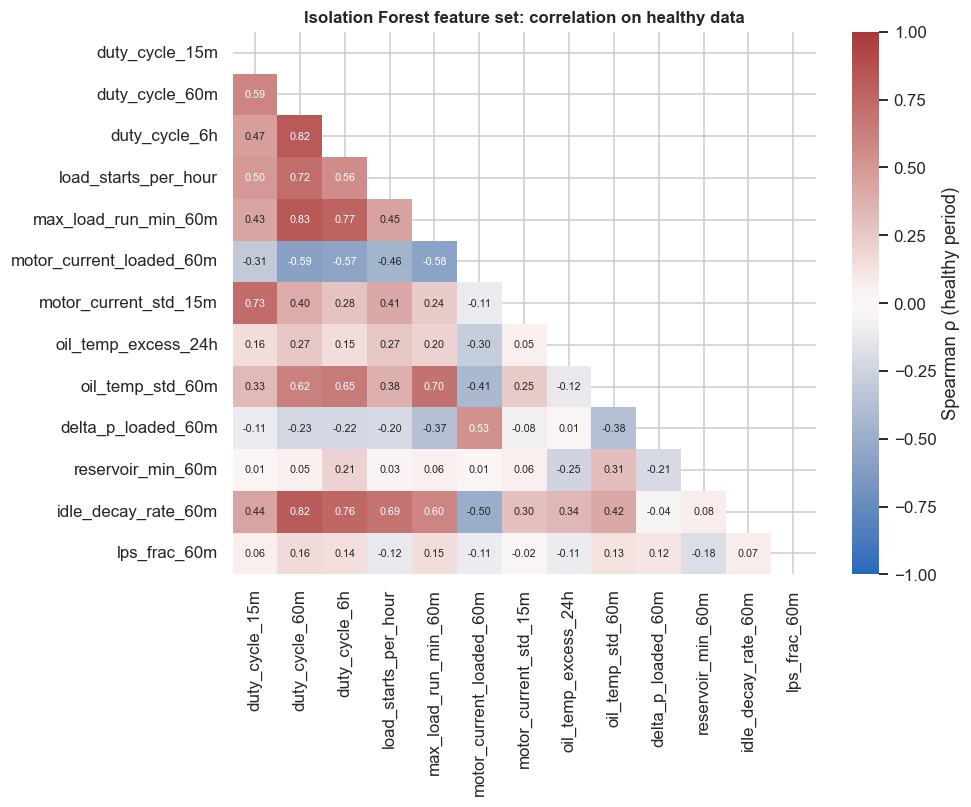

In [7]:
cols = params["metropt"]["models"]["isolation_forest"]["features"]
corr = healthy[cols].corr(method="spearman")
plt.figure(figsize=(9, 7.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool)), cmap="vlag", vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, cbar_kws={"label": "Spearman ρ (healthy period)"})
plt.title("Isolation Forest feature set: correlation on healthy data")
plt.tight_layout(); plt.show()

The duty-cycle windows and the maximum run length are strongly related, by design: they are views of the same behaviour at different time scales. The pneumatic (idle decay, reservoir minimum), thermal and electrical features carry largely separate information, which is what a multivariate detector needs.

## 6. Save

In [8]:
out = save_features_parquet(feats, ROOT / params["metropt"]["processed_parquet_path"])
bpath = save_baseline(baseline, ROOT / params["metropt"]["baseline_path"])
print(f"features -> {out.relative_to(ROOT)} ({out.stat().st_size / 1024**2:.1f} MB)")
print(f"baseline -> {bpath.relative_to(ROOT)}")

features -> data/processed/metropt_features.parquet (32.9 MB)
baseline -> models/feature_baseline.json
